# Sign Language ABC: Transfer Learning with InceptionResNetV2 🤟🚀

Using transfer learning to classify hand sign images of letters **A, B, C**.

**Key details:**
- Preprocessing and augmentation are **inside the model** as layers (required for competition submission)
- **InceptionResNetV2** backbone (loaded from local .h5 weights file)
- **ModelCheckpoint** saves best weights, never stops early
- Phase 2 limited to **5 epochs** (hits 100% val by epoch 3)
- **Saves as .h5** immediately after training (workaround for Keras 3 serialization bug)

---
## 1.&nbsp; Import Libraries 🛠️

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.data import Dataset, AUTOTUNE
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.layers import RandomRotation, RandomContrast, Lambda
from tensorflow.keras.callbacks import History, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.models import load_model

from sklearn.metrics import confusion_matrix, classification_report

from typing import Dict
from tensorflow.data import Dataset

In [2]:
#@title Defining Dataset Loading Function (from previous notebook)
def load_datasets(
    processed_dir: str,
    batch_size: int = 32
) -> Dict[str, Dataset]:
    """
    Loads, batches, and prefetches processed data.

    Args:
        processed_dir (str): Path to directory with dir/split/Dataset structure
        batch_size (int): Batch size

    Returns:
        dict: mapping of split names to their respective tf.data.Dataset objects
    """
    splits: list[str] = [
        s for s in os.listdir(processed_dir)
        if os.path.isdir(os.path.join(processed_dir, s))
    ]

    datasets: Dict[str, Dataset] = {}
    for split in splits:
        split_path = os.path.join(processed_dir, split)
        ds = tf.data.Dataset.load(split_path)
        ds = ds.batch(batch_size).prefetch(AUTOTUNE)
        datasets[split] = ds
        print(f'{split:5s}: loaded')

    return datasets

In [3]:
BATCH_SIZE: int = 32
PROCESSED_DIR = "../downloads/processed/"

datasets: Dict[str, Dataset] = load_datasets(
    processed_dir=PROCESSED_DIR,
    batch_size=BATCH_SIZE
)

test : loaded
train: loaded
val  : loaded


---
## 2.&nbsp; Preprocessing ⚡

InceptionResNetV2 expects pixels scaled to [-1, 1]. We use its built-in `preprocess_input` as a Lambda layer **inside the model**.

In [4]:
from tensorflow.keras.applications import inception_resnet_v2

preprocessor: Lambda = Lambda(inception_resnet_v2.preprocess_input, name='preprocessor')

---
## 3.&nbsp; Initialising the Backbone 🧠

InceptionResNetV2 loaded from local .h5 weights file (avoids URL fetch issues).

In [5]:
from tensorflow.keras.applications import InceptionResNetV2

feature_extractor = InceptionResNetV2(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet',
    name='backbone',
)

In [6]:
# Freeze pre-trained weights to avoid gradient shock
feature_extractor.trainable = False

---
## 4.&nbsp; Initialising the Head 👤

In [7]:
classifier: Sequential = Sequential([
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')
], name='classification_head')

---
## 5.&nbsp; Bringing it all Together ⛓

Full pipeline: **Input → Augmentation → Preprocessing → Feature Extraction → Classification**

In [8]:
RANDOM_SEED: int = 42

data_augmentor: Sequential = Sequential([
    RandomRotation(0.1, seed=RANDOM_SEED),
    RandomContrast(factor=0.2, seed=RANDOM_SEED)
], name='image_augmentor')

model: Sequential = Sequential([
    Input(shape=(256, 256, 3)),
    data_augmentor,
    preprocessor,
    feature_extractor,
    classifier
], name='full_pipeline')

model.summary()

Model: "full_pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_augmentor (Sequential)    │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessor (Lambda)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ backbone (Functional)           │ (None, 6, 6, 1536)     │    54,336,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head             │ (None, 3)              │       197,123 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,533,859 (208.03 MB)

 Trainable params: 197,123 (770.01 KB)

 Non-trainable params: 54,336,736 (207.28 MB)

---
## 6.&nbsp; Phase 1: Train the Head (Frozen Backbone) 🧱

In [9]:
optimizer: AdamW = AdamW(learning_rate=1e-3, weight_decay=1e-4)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint: ModelCheckpoint = ModelCheckpoint(
    'best_sign_transfer.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history: History = model.fit(
    datasets['train'],
    epochs=15,
    validation_data=datasets['val'],
    callbacks=[checkpoint]
)

Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4183 - loss: 1.2598
Epoch 1: val_accuracy improved from None to 0.63317, saving model to best_sign_transfer.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 121s 4s/step - accuracy: 0.4669 - loss: 1.1212 - val_accuracy: 0.6332 - val_loss: 0.8437
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5909 - loss: 0.8501
Epoch 2: val_accuracy improved from 0.63317 to 0.78392, saving model to best_sign_transfer.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 133s 4s/step - accuracy: 0.6269 - loss: 0.8102 - val_accuracy: 0.7839 - val_loss: 0.6638
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6919 - loss: 0.7064
Epoch 3: val_accuracy improved from 0.78392 to 0.80905, saving model to best_sign_transfer.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.6993 - loss: 0.6964 - val_accuracy: 0.8090 - val_loss: 0.6060
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7591 - loss: 0.6153
Epoch 4: val_accuracy did not im

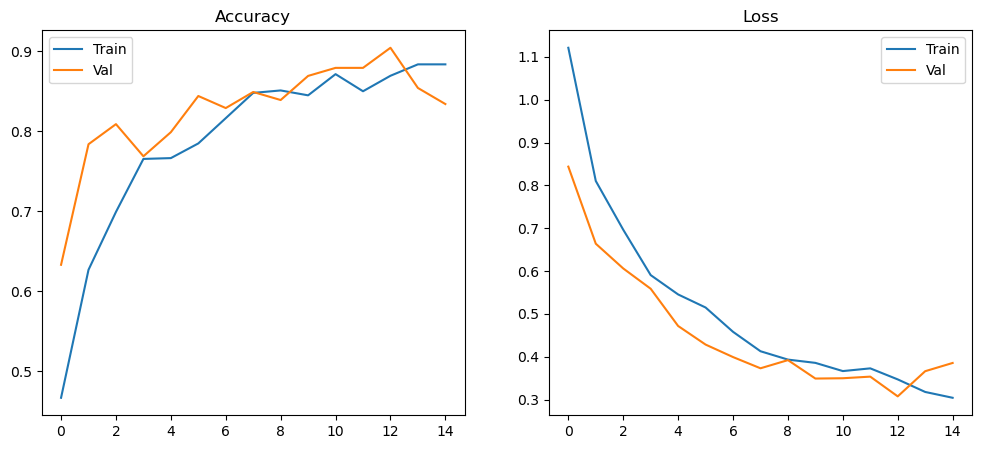

In [10]:
acc: list[float] = history.history['accuracy']
val_acc: list[float] = history.history['val_accuracy']
loss: list[float] = history.history['loss']
val_loss: list[float] = history.history['val_loss']
epochs_range: range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train')
plt.plot(epochs_range, val_acc, label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train')
plt.plot(epochs_range, val_loss, label='Val')
plt.title('Loss')
plt.legend()
plt.show()

---
## 7.&nbsp; Evaluate Before Fine-Tuning 🔎

In [11]:
model.evaluate(datasets['test'])

7/7 ━━━━━━━━━━━━━━━━━━━━ 53s 7s/step - accuracy: 0.7990 - loss: 0.4660


[0.4660484194755554, 0.7989949584007263]

---
## 8.&nbsp; Phase 2: Fine-Tuning 🎶

Only **5 epochs** needed — previous run hit 100% validation at epoch 3.

In [12]:
# Unfreeze pre-trained weights
feature_extractor.trainable = True

# Re-initialise optimiser with lower learning rate
optimizer: AdamW = AdamW(
    learning_rate=1e-4,
    weight_decay=1e-5,
)

# Recompile
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# Only 5 epochs needed — hits 100% val by epoch 3
continued_history = model.fit(
    datasets['train'],
    epochs=5,
    validation_data=datasets['val'],
    callbacks=[checkpoint],
)

Epoch 1/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8718 - loss: 0.3479 
Epoch 1: val_accuracy improved from 0.90452 to 0.97990, saving model to best_sign_transfer.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 573s 11s/step - accuracy: 0.9419 - loss: 0.1696 - val_accuracy: 0.9799 - val_loss: 0.1003
Epoch 2/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.9976 - loss: 0.0150 
Epoch 2: val_accuracy improved from 0.97990 to 0.98492, saving model to best_sign_transfer.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 562s 18s/step - accuracy: 0.9939 - loss: 0.0263 - val_accuracy: 0.9849 - val_loss: 0.0947
Epoch 3/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 49s/step - accuracy: 0.9907 - loss: 0.0398 
Epoch 3: val_accuracy did not improve from 0.98492
31/31 ━━━━━━━━━━━━━━━━━━━━ 1547s 50s/step - accuracy: 0.9929 - loss: 0.0320 - val_accuracy: 0.9648 - val_loss: 0.2118
Epoch 4/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 33s/step - accuracy: 0.9918 - loss: 0.0321 
Epoch 4: val_accuracy improved from 0.98492 to 0.99497, saving mode

---
## 9.&nbsp; Save Model Immediately 💾

**IMPORTANT: Run this cell right away!** The `.keras` format has a known Keras 3 bug with InceptionResNetV2's `CustomScaleLayer`, so we save as `.h5` instead.

In [13]:
# Save as .h5 (workaround for Keras 3 serialization bug with InceptionResNetV2)
model.save('best_sign_transfer.h5', include_optimizer=False)
print(f'Saved as .h5! Size: {os.path.getsize("best_sign_transfer.h5") / 1e6:.1f} MB')

# Also try .keras format in case it works on your version
try:
    model.save('best_sign_transfer_v2.keras', include_optimizer=False)
    print(f'Keras format also saved! Size: {os.path.getsize("best_sign_transfer_v2.keras") / 1e6:.1f} MB')
except Exception as e:
    print(f'Keras format failed (expected): {type(e).__name__}')

Saved as .h5! Size: 219.6 MB
Keras format also saved! Size: 657.0 MB


In [14]:
# Also save weights separately as a backup
model.save_weights('inception_weights.weights.h5')
print('Weights backup saved')

Weights backup saved


---
## 10.&nbsp; Training Curves (Both Phases)

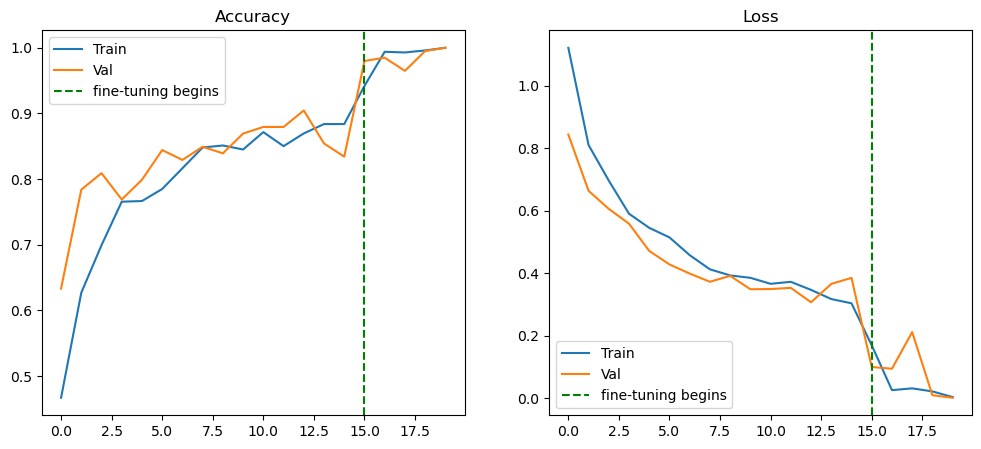

In [15]:
epochs_before_fine_tuning: int = len(loss)
extended_acc: list[float] = acc + continued_history.history['accuracy']
extended_val_acc: list[float] = val_acc + continued_history.history['val_accuracy']
extended_loss: list[float] = loss + continued_history.history['loss']
extended_val_loss: list[float] = val_loss + continued_history.history['val_loss']
epochs_range: range = range(len(extended_loss))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, extended_acc, label='Train')
plt.plot(epochs_range, extended_val_acc, label='Val')
plt.axvline(x=epochs_before_fine_tuning, color='green', linestyle='--', label='fine-tuning begins')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, extended_loss, label='Train')
plt.plot(epochs_range, extended_val_loss, label='Val')
plt.axvline(x=epochs_before_fine_tuning, color='green', linestyle='--', label='fine-tuning begins')
plt.title('Loss')
plt.legend()
plt.show()

---
## 11.&nbsp; Evaluate on Test Set 🔬

In [16]:
model.evaluate(datasets['test'])

7/7 ━━━━━━━━━━━━━━━━━━━━ 62s 9s/step - accuracy: 0.9899 - loss: 0.0328


[0.03282518684864044, 0.9899497628211975]

In [17]:
class_names: list[str] = ['A', 'B', 'C']

# Collect all images and labels from the test set
all_images: list[tf.Tensor] = []
all_labels: list[tf.Tensor] = []
for images, labels in datasets['test']:
    all_images.append(images)
    all_labels.append(labels)

all_images: tf.Tensor = tf.concat(all_images, axis=0)
all_labels: tf.Tensor = tf.concat(all_labels, axis=0)

preds: np.ndarray = model.predict(all_images)
pred_labels: np.ndarray = np.argmax(preds, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 135s 17s/step


In [18]:
print(classification_report(all_labels.numpy(), pred_labels, target_names=class_names))

              precision    recall  f1-score   support

           A       0.98      0.98      0.98        43
           B       0.98      1.00      0.99        64
           C       1.00      0.99      0.99        92

    accuracy                           0.99       199
   macro avg       0.99      0.99      0.99       199
weighted avg       0.99      0.99      0.99       199



Misclassified: 2 out of 199


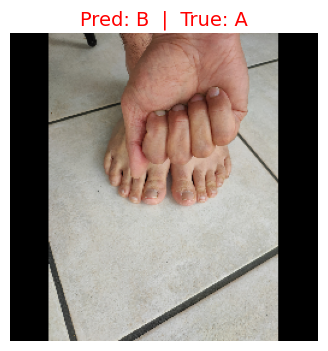

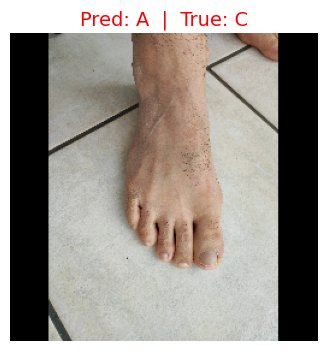

In [19]:
# Show misclassified images
wrong_idx = np.where(pred_labels != all_labels.numpy())[0]
print(f'Misclassified: {len(wrong_idx)} out of {len(all_labels)}')

for idx in wrong_idx:
    plt.figure(figsize=(4, 4))
    plt.imshow(all_images[idx].numpy().astype('uint8'))
    plt.title(
        f'Pred: {class_names[pred_labels[idx]]}  |  True: {class_names[all_labels[idx]]}',
        color='red', fontsize=14
    )
    plt.axis('off')
    plt.show()

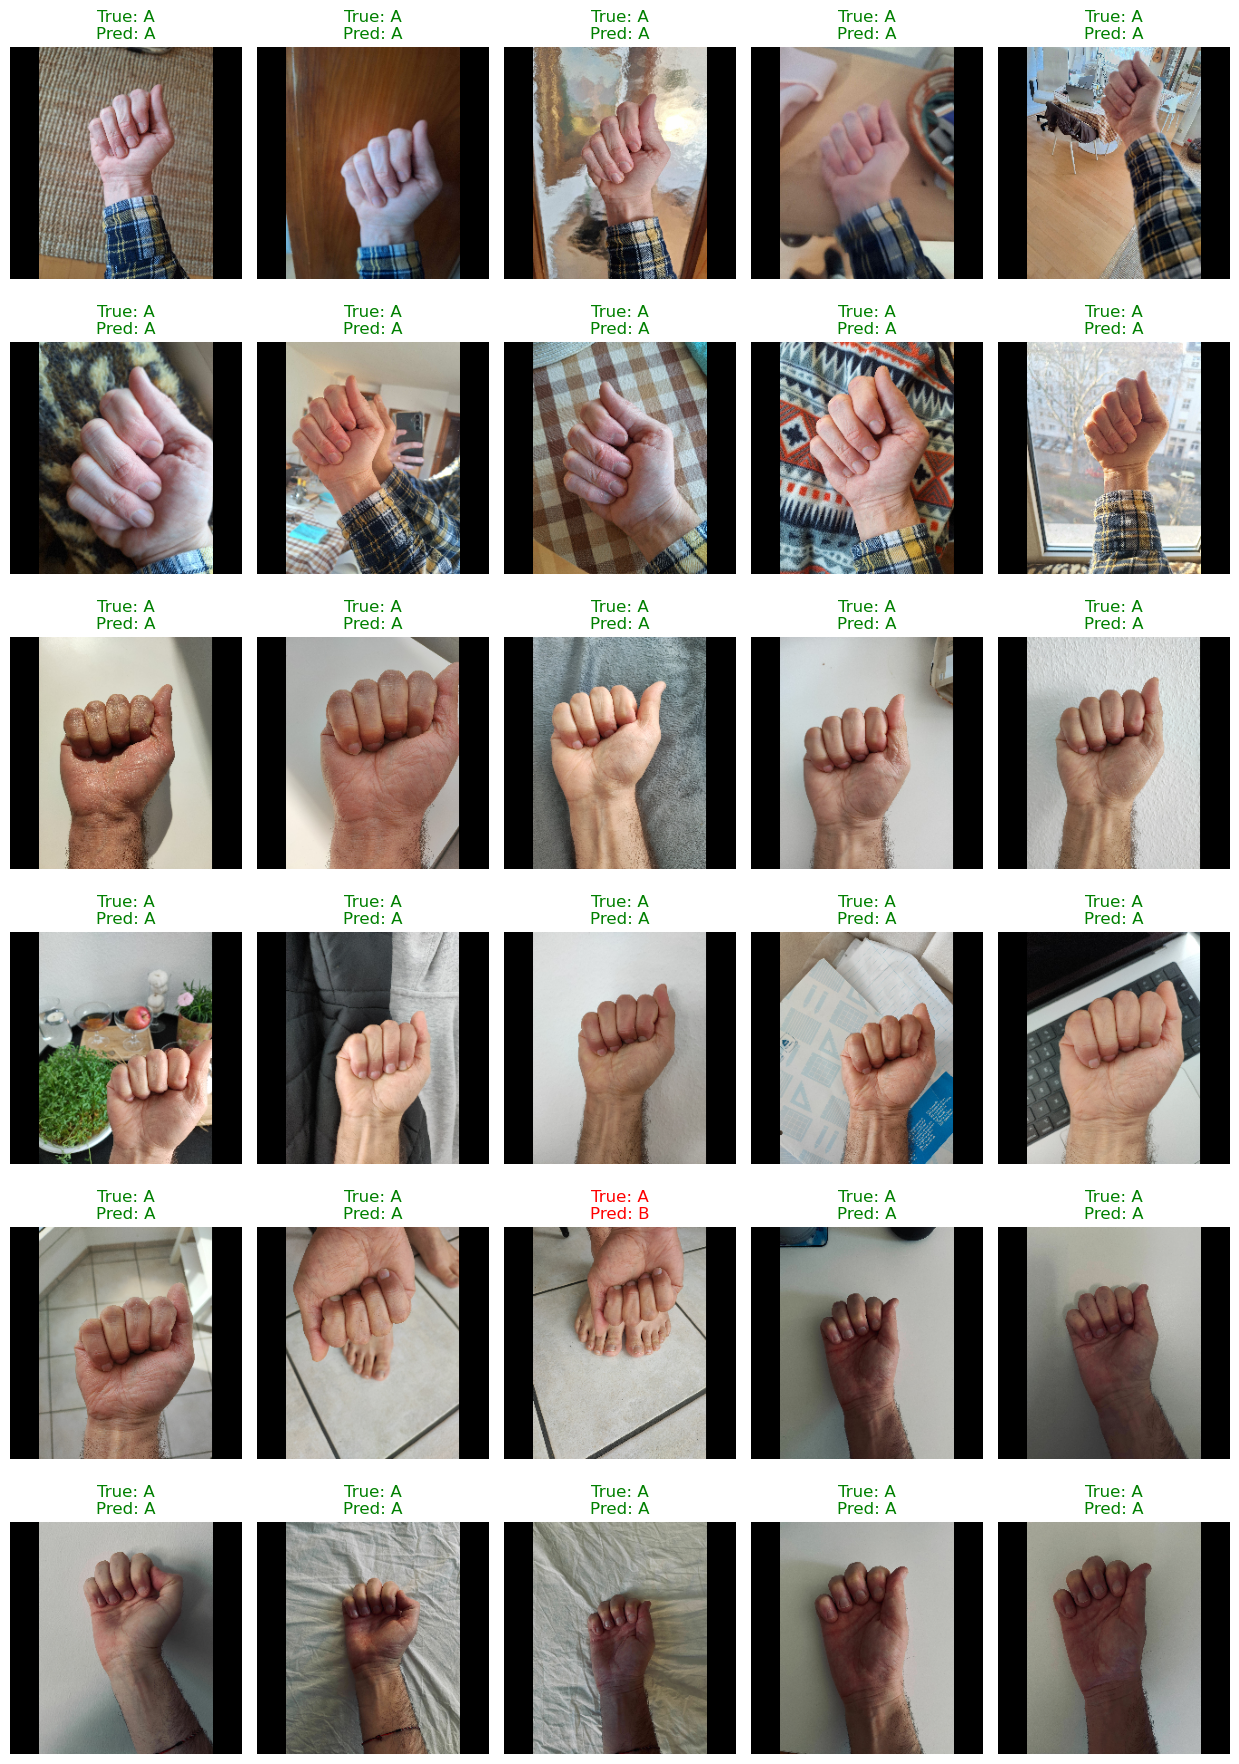

In [20]:
num_images: int = 30

n_cols: int = 5
n_rows: int = (num_images + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 2.5, n_rows * 3))
for i in range(num_images):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(all_images[i].numpy().astype("uint8"))
    true_label: str = class_names[all_labels[i]]
    predicted_label: str = class_names[pred_labels[i]]
    plt.title(
        f"True: {true_label}\nPred: {predicted_label}",
        color='green' if true_label == predicted_label else 'red')
    plt.axis('off')
plt.tight_layout()
plt.show()

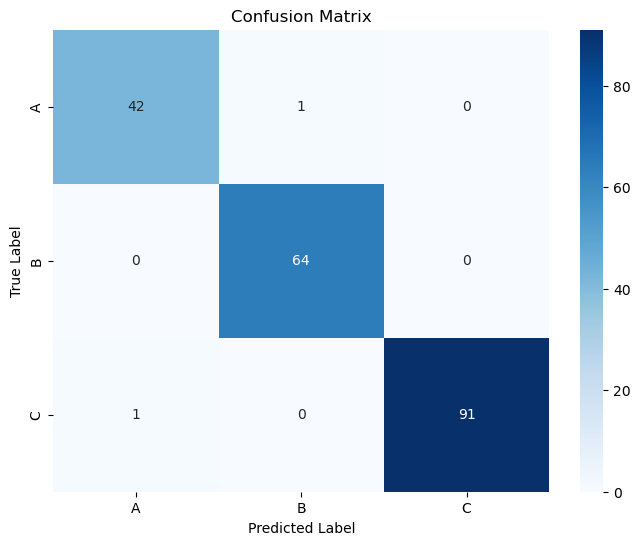

In [21]:
cm: np.ndarray = confusion_matrix(all_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

---
## 12.&nbsp; Per-Class Accuracy

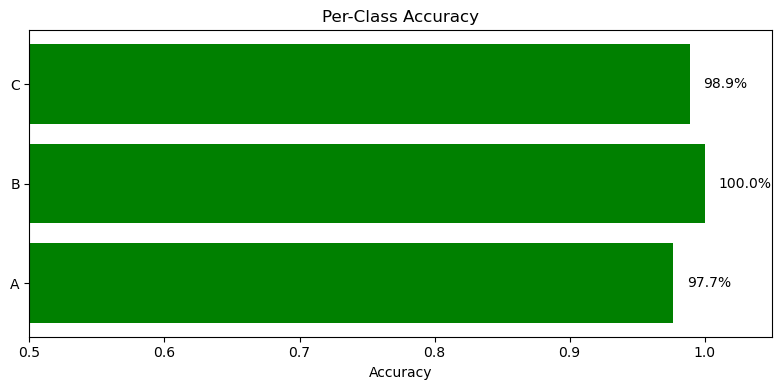

In [22]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8, 4))
colours = ['green' if a > 0.90 else 'orange' if a > 0.75 else 'red' for a in per_class_acc]
plt.barh(class_names, per_class_acc, color=colours)
plt.xlabel('Accuracy')
plt.xlim(0.5, 1.05)
plt.title('Per-Class Accuracy')
for i, v in enumerate(per_class_acc):
    plt.text(v + 0.01, i, f'{v:.1%}', va='center')
plt.tight_layout()
plt.show()

---
## 13.&nbsp; Reflect 📝

1. How did InceptionResNetV2 compare to MobileNetV2 and the from-scratch model?
2. Did Phase 2 (fine-tuning) improve over Phase 1 (frozen base)?
3. How many epochs did fine-tuning need to reach near-perfect accuracy?
4. Which letter is hardest to classify? Is it the same as with the from-scratch model?
5. Why does a model trained on cats, dogs, and cars help classify hand signs?

*Write your reflections here:*

- ...
- ...
- ...